In [56]:
import torch
from torch import nn

import numpy as np

from tqdm import tqdm_notebook

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output


In [192]:
mu = 0.01
L = 1000
A = torch.Tensor([[mu, 0], [0, L]])
x0 = torch.Tensor([10, 10])

A

tensor([[1.0000e-02, 0.0000e+00],
        [0.0000e+00, 1.0000e+03]])

In [87]:
class Noise(nn.Module):
    def __init__(self, iterations):
        super().__init__()
        self.noise = nn.Linear(2, iterations)

    def add_i(self, i):
        return self.noise.weight[i]


In [193]:

def method(x: torch.Tensor, B, noise, iterations, alpha=0):
    device = 'cpu'
    corr_L = (1 + alpha) / ((1 - alpha) ** 3) * L
    coef = ((1 - alpha) / (1 + alpha)) ** (3 / 2)
    h = 1 / L * coef
    s = (1 + alpha) ** 2 + alpha ** 2
    m = (1 - alpha) ** 2 - alpha ** 2
    q = mu / corr_L
    a = ((m - s) + ((s - m) ** 2 + 4 * m * q) ** 0.5) / 2 / m

    mu_corr = mu / 2
    x = x.to(device)
    u = x.to(device)
    y = x.to(device)
    for j in range(iterations):
        y = (a * u + x) / (1 + a)
        n = noise.add_i(j)
        gr = B @ y
        g = gr + n / torch.norm(n) * torch.norm(gr) * alpha
        u = (1 - a) * u + a * y - a / mu_corr * g
        x = y - h * g
    return x


def learn_noise(iterations: int, iter_learn: int, alpha):
    noise = Noise(iterations)
    device = 'cpu'
    x = x0.to(device)
    learning_rate = 1e-1
    optimizer = torch.optim.Adam(noise.parameters(), lr=learning_rate)
    losses = []
    for _ in tqdm_notebook(range(iter_learn)):
        x = x0.to(device)
        AA = A.to(device)
        x = method(x, AA, noise, iterations, alpha)
        l = -x @ AA @ x
        losses.append(l.item())
        l.backward()
        optimizer.step()
    return losses[-1]


def by_iterations(iters: list[int], iter_learn: int, alpha):
    rs = []
    for it in tqdm_notebook(iters):
        rs.append(learn_noise(it, iter_learn, alpha))
    return rs


In [145]:
c_1 = (2 ** 0.5 - 1) / 18 / np.sqrt(2) # from theorem

coef = np.sqrt(mu / L)

iters = list(range(500, 5500, 500))

In [246]:
rs0 = by_iterations(iters, 1, alpha=0)

/tmp/ipykernel_292052/1816611464.py:46: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for it in tqdm_notebook(iters):


  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_292052/1816611464.py:33: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for _ in tqdm_notebook(range(iter_learn)):


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [238]:
rs_c1 = by_iterations(iters, 100, alpha=c_1 * coef)

/tmp/ipykernel_292052/1816611464.py:46: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for it in tqdm_notebook(iters):


  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_292052/1816611464.py:33: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for _ in tqdm_notebook(range(iter_learn)):


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

In [222]:
rs_01 = by_iterations(iters, 100, alpha=0.1 * coef)

/tmp/ipykernel_292052/1816611464.py:46: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for it in tqdm_notebook(iters):


  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_292052/1816611464.py:33: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for _ in tqdm_notebook(range(iter_learn)):


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

In [223]:
rs_05 = by_iterations(iters, 100, alpha=coef / 2)

/tmp/ipykernel_292052/1816611464.py:46: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for it in tqdm_notebook(iters):


  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_292052/1816611464.py:33: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for _ in tqdm_notebook(range(iter_learn)):


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

In [224]:
rs_1 = by_iterations(iters, 100, alpha=coef)

/tmp/ipykernel_292052/1816611464.py:46: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for it in tqdm_notebook(iters):


  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_292052/1816611464.py:33: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for _ in tqdm_notebook(range(iter_learn)):


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

In [229]:
rs_2 = by_iterations(iters, 100, alpha=2 * coef)

/tmp/ipykernel_292052/1816611464.py:46: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for it in tqdm_notebook(iters):


  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_292052/1816611464.py:33: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for _ in tqdm_notebook(range(iter_learn)):


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

In [232]:
rs_5 = by_iterations(iters, 100, alpha=5 * coef)

/tmp/ipykernel_292052/1816611464.py:46: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for it in tqdm_notebook(iters):


  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_292052/1816611464.py:33: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for _ in tqdm_notebook(range(iter_learn)):


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
rs_5 = by_iterations(iters, 100, alpha=0.3)

In [ ]:
with sns.plotting_context("notebook"), sns.axes_style("darkgrid"):
    plt.figure(figsize=(10, 6), dpi=120)
    # plt.semilogy(iters, -np.array(rs), label='Nesterov accelerated with noise')
    plt.semilogy(iters, 0.5 * np.exp(-np.array(iters) * mu / L), label=r'$exp\left(-\frac{\mu}{L}k\right)$')
    plt.semilogy(iters, 0.5 * np.exp(-np.array(iters) * np.sqrt(mu / L) / 10 / np.sqrt(2)), label=r'$exp\left(-\frac{1}{10\sqrt{2}}\sqrt{\frac{\mu}{L}}k\right)$')
    plt.semilogy(iters, -np.array(rs_1), label='Nesterov accelerated without noise')
    plt.xlabel(r"Iterations $N$")
    plt.ylabel(r"$f(x^N) - f^*$")
    plt.title(fr"$\mu = {mu:.2f}, L = {L}$, " + r"$\alpha = \frac{\sqrt{2} - 1}{18 \sqrt{2}}\sqrt{\frac{\mu}{L}}$", pad=10)
    plt.legend()

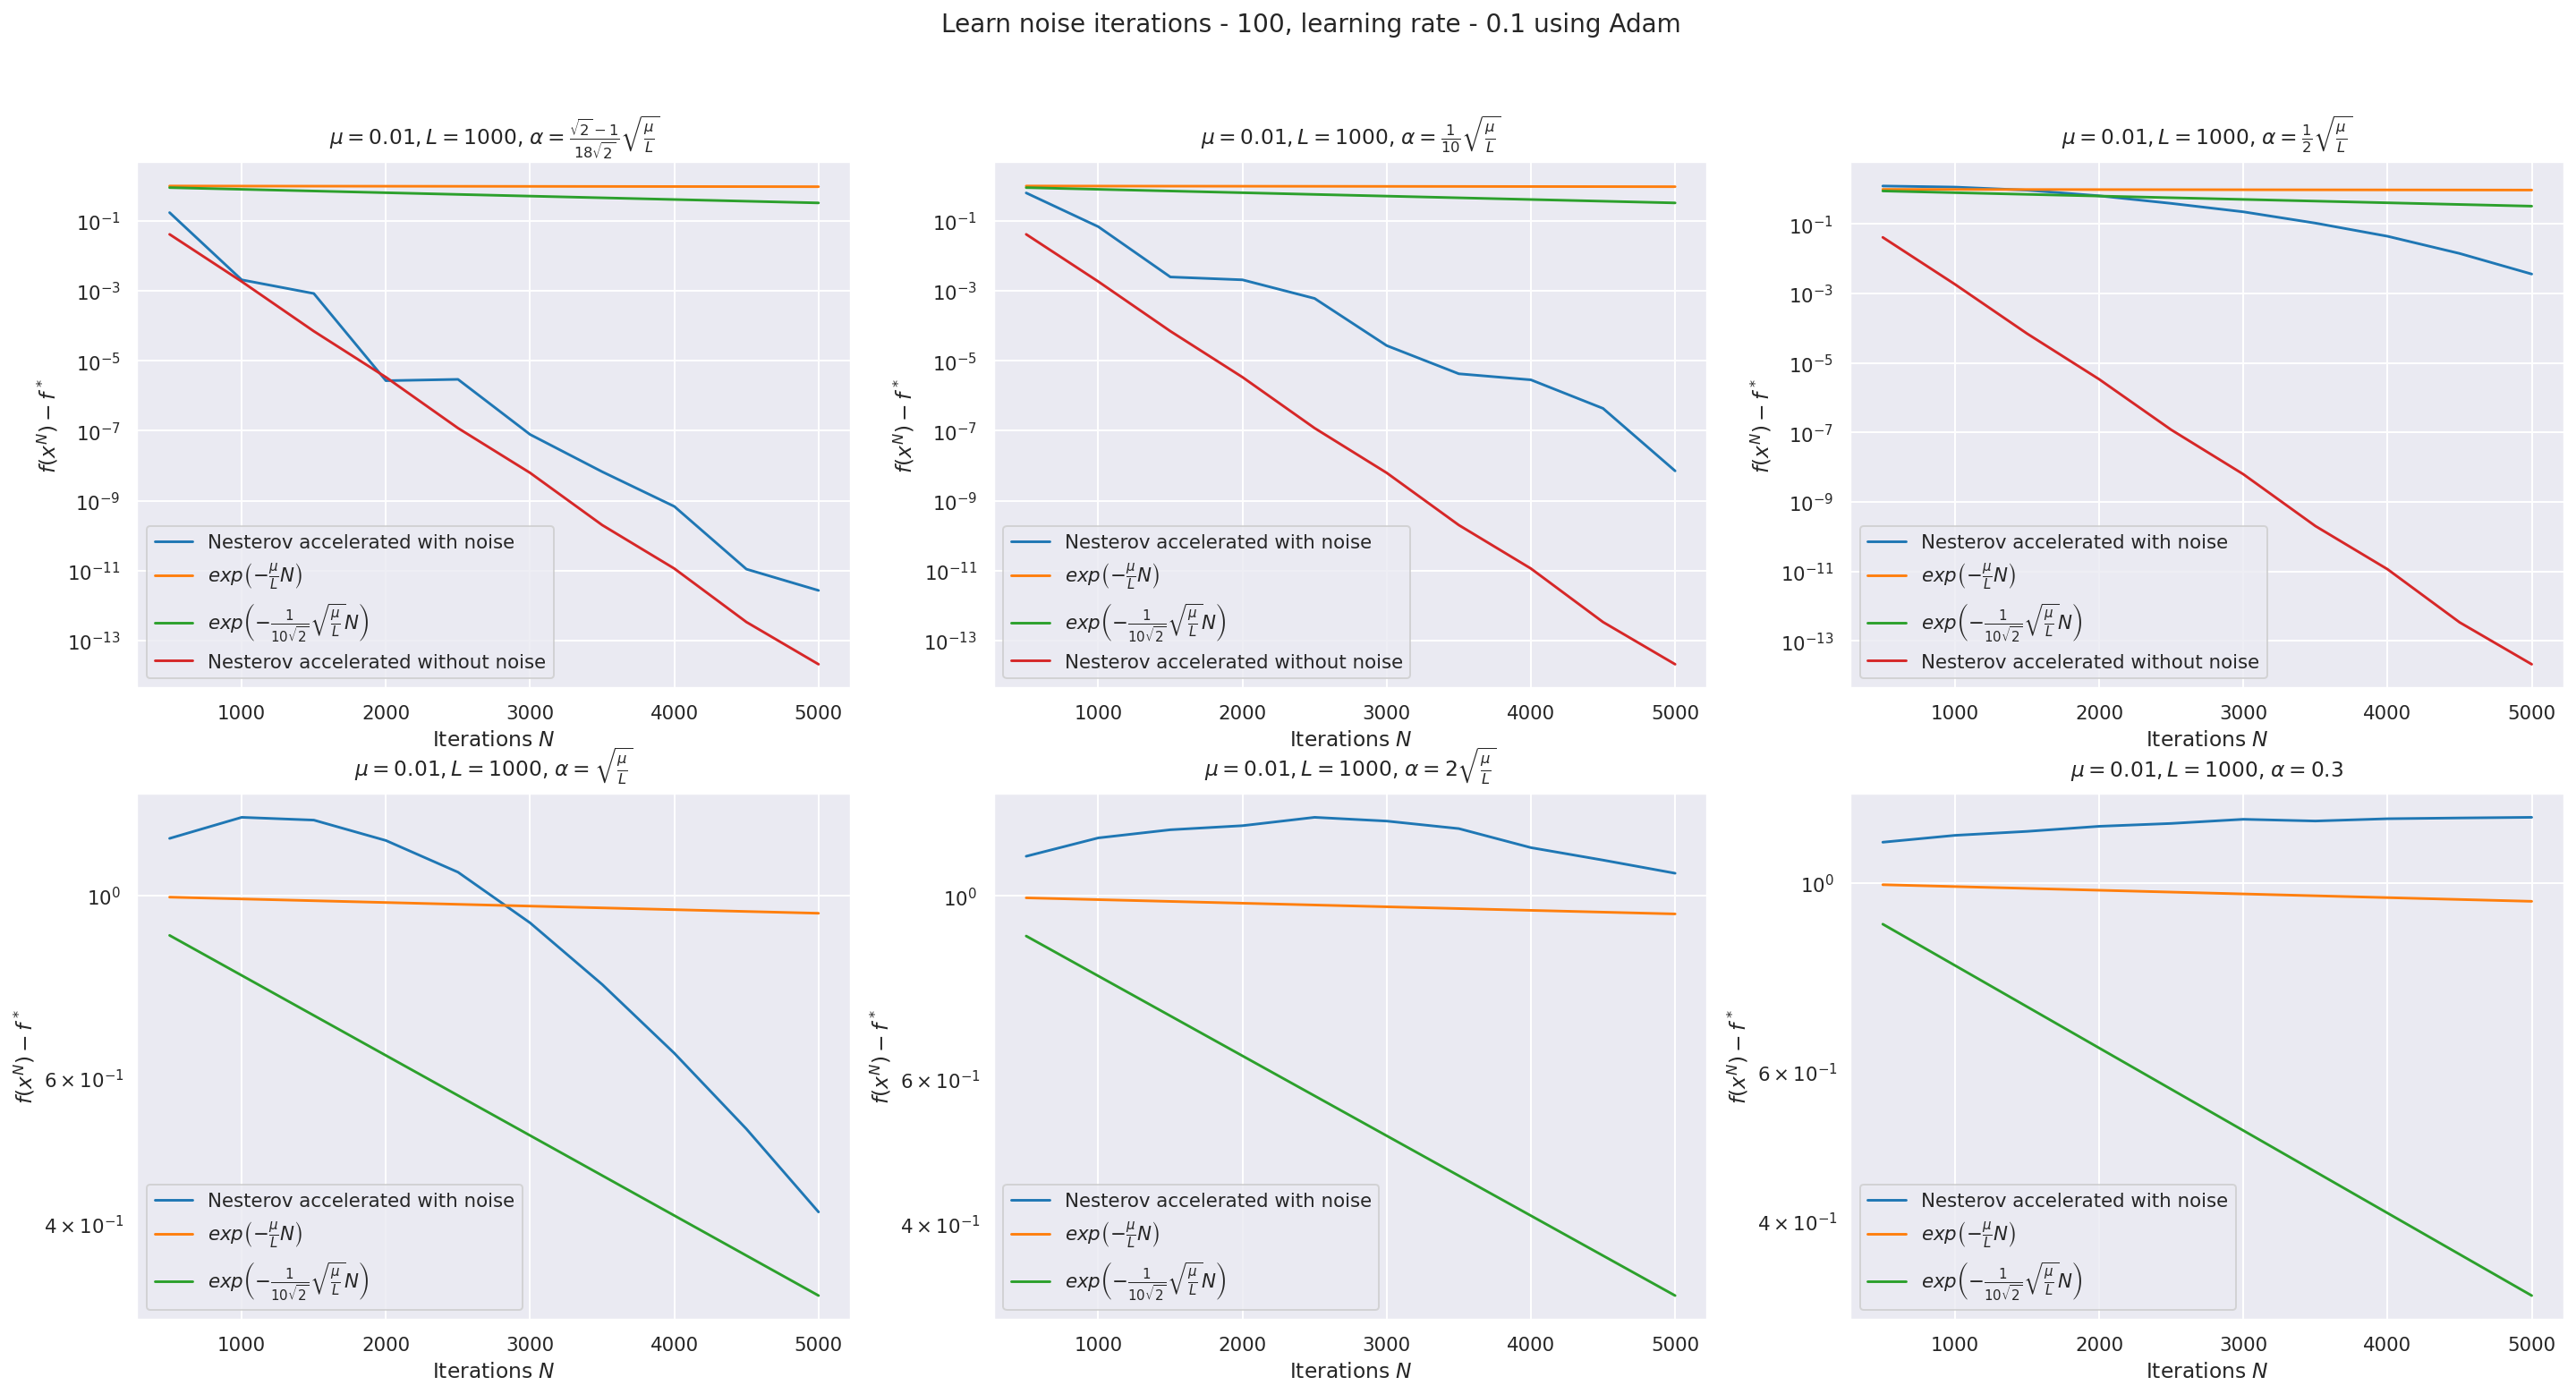

In [257]:

with sns.plotting_context("notebook"), sns.axes_style("darkgrid"):
    plt.figure(figsize=(25, 12), dpi=140)

    plt.subplot(2, 3, 1)
    plt.semilogy(iters, -np.array(rs_c1), label='Nesterov accelerated with noise')
    plt.semilogy(iters, np.exp(-np.array(iters) * mu / L), label=r'$exp\left(-\frac{\mu}{L}N\right)$')
    plt.semilogy(iters, np.exp(-np.array(iters) * np.sqrt(mu / L) / 10 / np.sqrt(2)), label=r'$exp\left(-\frac{1}{10\sqrt{2}}\sqrt{\frac{\mu}{L}}N\right)$')
    plt.semilogy(iters, -np.array(rs0), label='Nesterov accelerated without noise')
    plt.xlabel(r"Iterations $N$")
    plt.ylabel(r"$f(x^N) - f^*$")
    plt.title(fr"$\mu = {mu:.2f}, L = {L}$, " + r"$\alpha = \frac{\sqrt{2} - 1}{18 \sqrt{2}}\sqrt{\frac{\mu}{L}}$", pad=10)
    plt.legend()

    plt.subplot(2, 3, 2)
    plt.semilogy(iters, -np.array(rs_01), label='Nesterov accelerated with noise')
    plt.semilogy(iters, np.exp(-np.array(iters) * mu / L), label=r'$exp\left(-\frac{\mu}{L}N\right)$')
    plt.semilogy(iters, np.exp(-np.array(iters) * np.sqrt(mu / L) / 10 / np.sqrt(2)), label=r'$exp\left(-\frac{1}{10\sqrt{2}}\sqrt{\frac{\mu}{L}}N\right)$')
    plt.semilogy(iters, -np.array(rs0), label='Nesterov accelerated without noise')
    plt.xlabel(r"Iterations $N$")
    plt.ylabel(r"$f(x^N) - f^*$")
    plt.title(fr"$\mu = {mu:.2f}, L = {L}$, " + r"$\alpha = \frac{1}{10}\sqrt{\frac{\mu}{L}}$", pad=10)
    plt.legend()

    plt.subplot(2, 3, 3)
    plt.semilogy(iters, -np.array(rs_05), label='Nesterov accelerated with noise')
    plt.semilogy(iters, np.exp(-np.array(iters) * mu / L), label=r'$exp\left(-\frac{\mu}{L}N\right)$')
    plt.semilogy(iters, np.exp(-np.array(iters) * np.sqrt(mu / L) / 10 / np.sqrt(2)), label=r'$exp\left(-\frac{1}{10\sqrt{2}}\sqrt{\frac{\mu}{L}}N\right)$')
    plt.semilogy(iters, -np.array(rs0), label='Nesterov accelerated without noise')
    plt.xlabel(r"Iterations $N$")
    plt.ylabel(r"$f(x^N) - f^*$")
    plt.title(fr"$\mu = {mu:.2f}, L = {L}$, " + r"$\alpha = \frac{1}{2}\sqrt{\frac{\mu}{L}}$", pad=10)
    plt.legend()


    plt.subplot(2, 3, 4)
    plt.semilogy(iters, -np.array(rs_1), label='Nesterov accelerated with noise')
    plt.semilogy(iters, np.exp(-np.array(iters) * mu / L), label=r'$exp\left(-\frac{\mu}{L}N\right)$')
    plt.semilogy(iters, np.exp(-np.array(iters) * np.sqrt(mu / L) / 10 / np.sqrt(2)), label=r'$exp\left(-\frac{1}{10\sqrt{2}}\sqrt{\frac{\mu}{L}}N\right)$')
    #plt.semilogy(iters, -np.array(rs_1), label='Nesterov accelerated without noise')
    plt.xlabel(r"Iterations $N$")
    plt.ylabel(r"$f(x^N) - f^*$")
    plt.title(fr"$\mu = {mu:.2f}, L = {L}$, " + r"$\alpha = \sqrt{\frac{\mu}{L}}$", pad=10)
    plt.legend()


    plt.subplot(2, 3, 5)
    plt.semilogy(iters, -np.array(rs_2), label='Nesterov accelerated with noise')
    plt.semilogy(iters, np.exp(-np.array(iters) * mu / L), label=r'$exp\left(-\frac{\mu}{L}N\right)$')
    plt.semilogy(iters, np.exp(-np.array(iters) * np.sqrt(mu / L) / 10 / np.sqrt(2)), label=r'$exp\left(-\frac{1}{10\sqrt{2}}\sqrt{\frac{\mu}{L}}N\right)$')
    #plt.semilogy(iters, -np.array(rs_2), label='Nesterov accelerated without noise')
    plt.xlabel(r"Iterations $N$")
    plt.ylabel(r"$f(x^N) - f^*$")
    plt.title(fr"$\mu = {mu:.2f}, L = {L}$, " + r"$\alpha = 2\sqrt{\frac{\mu}{L}}$", pad=10)
    plt.legend()

    plt.subplot(2, 3, 6)
    plt.semilogy(iters, -np.array(rs_5), label='Nesterov accelerated with noise')
    plt.semilogy(iters, np.exp(-np.array(iters) * mu / L), label=r'$exp\left(-\frac{\mu}{L}N\right)$')
    plt.semilogy(iters, np.exp(-np.array(iters) * np.sqrt(mu / L) / 10 / np.sqrt(2)), label=r'$exp\left(-\frac{1}{10\sqrt{2}}\sqrt{\frac{\mu}{L}}N\right)$')
    #plt.semilogy(iters, -np.array(rs_5), label='Nesterov accelerated without noise')
    plt.xlabel(r"Iterations $N$")
    plt.ylabel(r"$f(x^N) - f^*$")
    plt.title(fr"$\mu = {mu:.2f}, L = {L}$, " + r"$\alpha = 0.3$", pad=10)
    plt.legend()


    plt.suptitle(fr"Learn noise iterations - 100, learning rate - 0.1 using Adam")
    plt.show()